# Unzip the data and load It from google drive

In [ ]:
# Install gdown in the Kaggle environment
!pip install gdown

In [ ]:


import gdown


file_id = '1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-'
url = f'https://drive.google.com/uc?id={file_id}'

# Download the zip file directly to Kaggle's fast working directory
output_path = '/kaggle/working/dataset.zip'
gdown.download(url, output_path, quiet=False)

In [ ]:
!unzip -q /kaggle/working/dataset.zip -d /kaggle/working/fast_dataset/

In [ ]:
!pip install pafy youtube-dl

In [ ]:
!pip install -U albumentations

In [ ]:

import os
import cv2
import pafy
import math
import random
import numpy as np
import pandas as pd
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt
from moviepy.editor import *
%matplotlib inline
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
import albumentations as A




In [ ]:
from tensorflow.keras.layers import ConvLSTM2D
from tensorflow.keras.layers import TimeDistributed
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import (
    Accuracy, Precision, Recall, AUC, BinaryAccuracy,
    FalsePositives, FalseNegatives, TruePositives, TrueNegatives
)
from tensorflow.keras import layers, models, optimizers, callbacks, applications
from tensorflow.keras.models import Model, load_model
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
seed_constant = 20
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

### Visualize random videos for both categories

In [ ]:
DATA_DIR = "/kaggle/working/fast_dataset/Shop DataSet"
CLASSES = ['non shop lifters', 'shop lifters']

In [ ]:
classes_names = os.listdir(DATA_DIR)
print(classes_names)

# Preprocess the DataSet


In [ ]:
# Specify the frames size for each video
IMAGE_HEIGHT, IMAGE_WIDTH = 128,128
# Specify the number of frames of a video will be fed to the model as one sequence
SEQUENCE_LENGTH = 24



In [ ]:
# Define Augmentation Pipeline
aug_pipeline = A.ReplayCompose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=15, p=0.3),
    
])

In [ ]:
def preprocess_video(video_path, target_frames=24, size=(64,64), is_training=False):
  """
  This function will extract the frames from the video after resizing and normalizing them.
  Args:
    video_path: Path to the video file
    target_frames: Number of frames to extract from the video
    size: Size to resize the frames to
  Returns:
    frames: List of NumPy arrays containing the extracted frames
  """
  frames_list = []
  video_reader = cv2.VideoCapture(video_path)
  # Get the total number of frames in the video
  video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

  # Calculate the interval after which frames will be added to the list
  skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH),1)
  # Iterate over the video frames
  for frame_counter in range(SEQUENCE_LENGTH):
    # Set the current frame position of the video
    video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
    # Reading the frame from the video
    success, frame = video_reader.read()
    if not success:
            # If video ends early, pad with a black frame or the last valid frame >> To ensure that the model always gets exactly 24 frames
            frame = np.zeros((size[1], size[0], 3), dtype="float32") # (224,224,3) of zeros
    else:
      # Resize the frame to fixed height and width
      resized_frame = cv2.resize(frame, size)
      # Convert to RGB
      rgb_frame = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB)
      # Normalization
      normalized_frame = rgb_frame.astype(np.float32) / 255.0
    frames_list.append(normalized_frame)
  video_reader.release()
  # convert to array
  video_frames = np.array(frames_list)

  # Apply Augmentation (Only if training)
  if is_training:
      #  Record the random transformations applied to the FIRST frame
      recorded_transform = aug_pipeline(image=video_frames[0])

      #  Apply that EXACT same transformation to EVERY frame in the video
      for i in range(len(video_frames)):
          # We use the 'replay' dictionary to force the exact same rotation/brightness
          video_frames[i] = A.ReplayCompose.replay(recorded_transform['replay'], image=video_frames[i])['image']

  return video_frames

### Create a Function for Dataset Creation

This approach is memory consuming for RAM in colab so we will use another approach

In [ ]:
# frames_list, labels, video_paths = create_dataset(data_dir=DATA_DIR,classes=classes_names)

We will Use Data Generator

In [ ]:
all_paths = []
all_labels = []
all_classes = []
for class_index, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATA_DIR, class_name)
    valid_extensions = (".mp4", ".avi", ".mov")

    file_names = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_extensions)]

    for file_name in file_names:
        all_paths.append(os.path.join(class_dir, file_name))
        all_labels.append(class_index)
        all_classes.append(class_name)

# 2. Split the PATHS into Train (70%), Val (15%), Test (15%)
# First split: Separate Test (15%)
X_temp_paths, X_test_paths, y_temp, y_test, c_temp, c_test = train_test_split(
    all_paths, all_labels, all_classes, test_size=0.15, stratify=all_labels, random_state=42
)

# Second split: Separate Train (70%) and Val (15%)
val_ratio = 0.15 / 0.85 # Calculate relative proportion
X_train_paths, X_val_paths, y_train, y_val, c_train, c_val = train_test_split(
    X_temp_paths, y_temp, c_temp, test_size=val_ratio, stratify=y_temp, random_state=42
)

print(f"Train videos: {len(X_train_paths)} | Val videos: {len(X_val_paths)} | Test videos: {len(X_test_paths)}")

In [ ]:
import tensorflow as tf
import math
# we create a class that inherit from tf.keras.utils.Sequence
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, video_paths, labels, class_names, batch_size=8, target_frames=24, is_training=False):
        self.video_paths = video_paths
        self.labels = labels
        self.class_names = class_names
        self.batch_size = batch_size
        self.target_frames = target_frames
        self.is_training = is_training

        # Create an index for each video to help with batching and shuffling
        self.indices = np.arange(len(self.video_paths)) # We Have 855 video so we have indecies from (0, .... to 854)
        if self.is_training:
            np.random.shuffle(self.indices) # We shuffle the indices of the videos


    def __len__(self):
        # Tells TensorFlow how many batches make up one full epoch
        return math.ceil(len(self.video_paths) / self.batch_size) # 855/8 = 106.875 >> math.ceil convert it to (107) so we will have 107 batches

    def __getitem__(self, index):
        # 1. Figure out which specific videos belong in this batch
        # start >> index * self.batch_size , end >>  (index + 1) * self.batch_size
        # Ex for first batch (batch 0) > index = 0 > self.indices[0*8:(0+1)*8] > self.indices[0:8] > will grab the first 8 videos from the shuffled list
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size] # index is the batch number
        batch_paths = [self.video_paths[i] for i in batch_indices] # Loop over the batch indices to Extract the video_paths through it's index > i
        batch_labels = [self.labels[i] for i in batch_indices] # Get the class label that match this path 1 for shop lifters and 0 for non shop lifters
        batch_classes = [self.class_names[i] for i in batch_indices] # Get the class name (string)

        X_batch = []

        # 2. Process just those few videos
        for path, cls_name in zip(batch_paths, batch_classes):
            # Apply augmentation ONLY if it's the training set AND it's a shoplifter
            need_aug = self.is_training and (cls_name == "shop lifters")

            # Apply the preprocess_video function we have created
            frames = preprocess_video(path, target_frames=self.target_frames, is_training=need_aug)
            X_batch.append(frames)

        # 3. Return the batch to the GPU
        return np.array(X_batch), np.array(batch_labels)

    def on_epoch_end(self):
        # Shuffle the data after every epoch so the model doesn't memorize the order
        if self.is_training:
            np.random.shuffle(self.indices)

### Split the Dataset

In [ ]:
# Create the Train Generator (Augmentation ON, Shuffling ON)
train_generator = VideoDataGenerator(X_train_paths, y_train, c_train, batch_size=8, is_training=True)

# Create the Val and Test Generators (Augmentation OFF, Shuffling OFF)
val_generator = VideoDataGenerator(X_val_paths, y_val, c_val, batch_size=8, is_training=False)
test_generator = VideoDataGenerator(X_test_paths, y_test, c_test, batch_size=8, is_training=False)

In [ ]:
train_generator

### Visualize the training data after applying preprocessing on it

In [ ]:
# Get the first batch from the train_generator
X_batch, y_batch = train_generator[0]
X_batch.shape, y_batch.shape

In [ ]:
#y_batch # Contain 8 labels [0,1,0,1,1,0,1,0]
#X_batch # 8> the batch we have 8 videos per batch
        # 24 the sequence we have 24 frames per video


In [ ]:
len(X_batch)

In [ ]:
len(X_batch[0]) # we have 24 frames

In [ ]:
# Select only the shoplifter labels because they are what we apply data augmentation on it
# np.where return a tuple of where is indices = 1 so if it find them in (2,5) it will return ([2,5],) so we use [0] to get the list
shop_lifter_indices = np.where(y_batch == 1)[0]

if len(shop_lifter_indices) > 0:
    # Grab the first shop lifter in this batch
    sample_index = shop_lifter_indices[0]  # for ex store 2 This tells us to select the 3rd video in the batch we have (8 videos per batch)
    title = "Class: Shop Lifter (Augmented)"
else:
    # If there happened to be no shop lifters in this random batch, just grab the first video
    sample_index = 0
    title = "Class: Non-Shop Lifter (Unchanged)"

# Extract that specific video from the batch
video_sample = X_batch[sample_index] # X_batch[2]

In [ ]:
sample_index

In [ ]:
len(video_sample)

In [ ]:
# Plot 6 evenly spaced frames from the 24-frame sequence
num_frames_to_show = 6
# Pick 6 indices evenly spaced between 0 and 23
# np.linespace generate random numbers from 0 to 23 to get frames from the beggining of the video, mid and end
indices_to_show = np.linspace(0, 23, num_frames_to_show, dtype=int)

fig, axes = plt.subplots(1, num_frames_to_show, figsize=(20, 4))
fig.suptitle(f"Generator Check - {title}", fontsize=16)



for i, frame_idx in enumerate(indices_to_show):
    # The generator already converted it to RGB and scaled it to [0, 1]
    # So matplotlib will display it perfectly without any extra work!
    axes[i].imshow(video_sample[frame_idx])
    axes[i].set_title(f"Frame {frame_idx}")
    axes[i].axis('off')

plt.show()

# Implement the ConvLSTM Approach

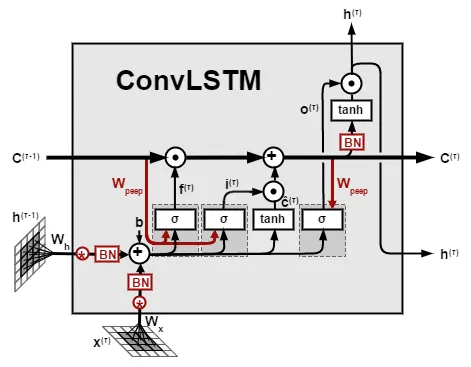

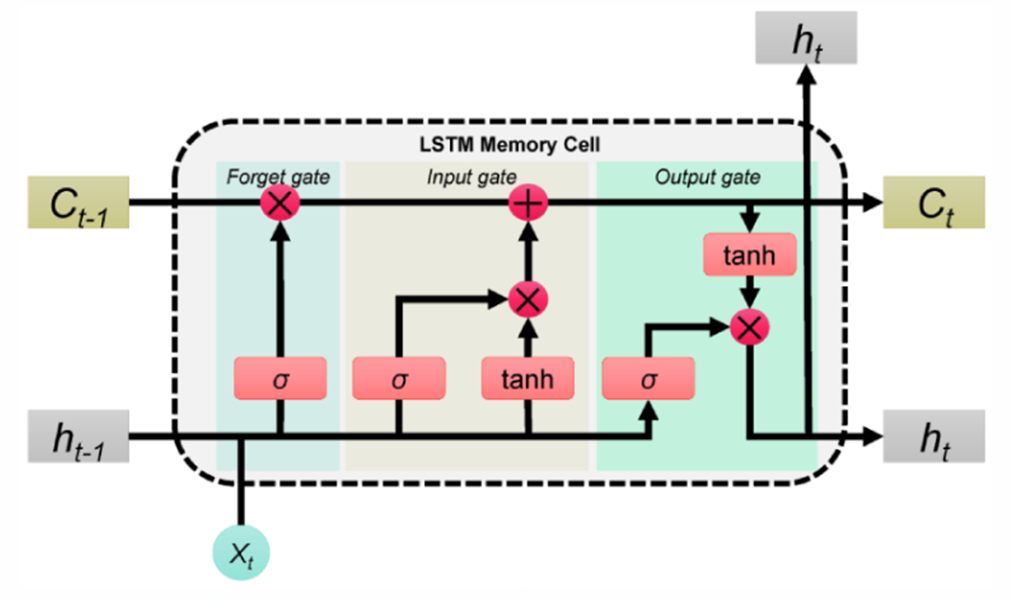

### Construct the Model

In [ ]:
!mkdir /kaggle/working/models

In [ ]:
save_path= "/kaggle/working/models"

### Compile and Train the Model

In [ ]:
def get_callbacks(model_name):
  callbacks = []
  rl = ReduceLROnPlateau(monitor="val_accuracy",
                         patience=9,
                         verbose=1,
                         factor=0.5,
                         min_lr=0.00001)
  callbacks.append(rl)
  early_stopping = EarlyStopping(monitor="val_accuracy",
                                 patience=9,
                                 verbose=1,
                                 mode="max")

  callbacks.append(early_stopping)
  checkpoint = ModelCheckpoint(filepath=save_path + "/" + model_name + ".keras",
                               monitor= "val_accuracy",
                               mode="max",
                               save_best_only=True)
  callbacks.append(checkpoint)

  return callbacks

### The model is overfitting

# Use two steps approach by using CNN + LSTM Seperatly


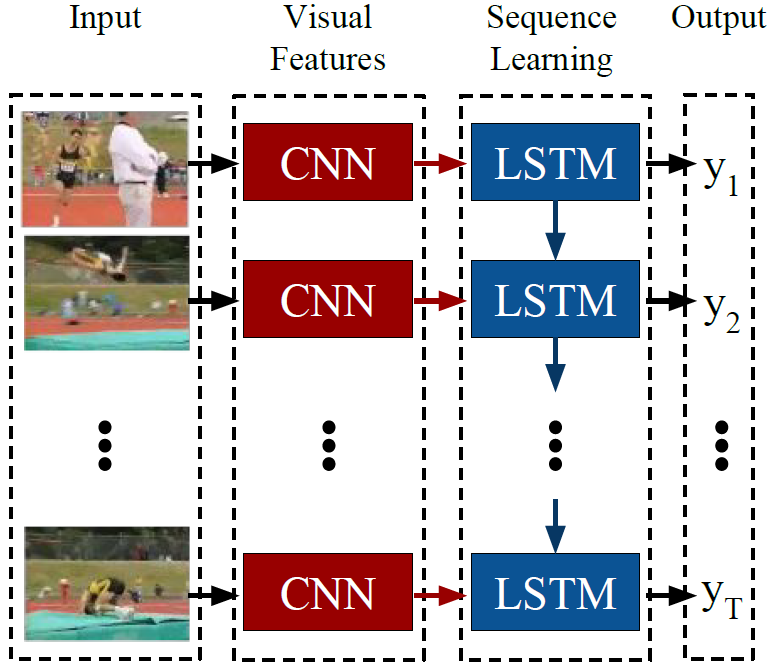


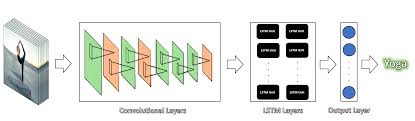

In [ ]:
def create_LRCN_model():
  model = Sequential()

  model.add(TimeDistributed(Conv2D(16, (3,3), padding="same", activation="relu"),
                            input_shape= (SEQUENCE_LENGTH,IMAGE_HEIGHT, IMAGE_WIDTH,3)))
  model.add(TimeDistributed(MaxPooling2D((2,2))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(32, (3,3), padding="same", activation="relu")))
  model.add(TimeDistributed(MaxPooling2D((2,2))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(32, (3,3), padding="same", activation="relu")))
  model.add(TimeDistributed(MaxPooling2D((2,2))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(64, (3,3), padding="same", activation="relu")))
  model.add(TimeDistributed(MaxPooling2D((2,2))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(64, (3,3), padding="same", activation="relu")))
  model.add(TimeDistributed(MaxPooling2D((2,2))))

  model.add(TimeDistributed(Flatten()))

  model.add(LSTM(32))

  model.add(Dense(1, activation="sigmoid"))

  return model



In [ ]:
LRCN_model = create_LRCN_model()

In [ ]:
LRCN_model.summary()

In [ ]:
#plot_model(LRCN_model, to_file=save_path + "/LRCN_model.png", show_shapes=True, show_layer_names=True)

In [ ]:
LRCN_model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-4),
    loss = "binary_crossentropy",
    metrics= ["accuracy"]
)

In [ ]:
LRCN_cb = get_callbacks(model_name= "LRCN_Model")

In [ ]:
history_lrcn = LRCN_model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=LRCN_cb
)

In [ ]:
LRCN_Model = load_model("/kaggle/working/models/LRCN_Model.keras")

In [ ]:
LRCN_Model.evaluate(test_generator)

In [ ]:
y_true_lrcn = np.concatenate([y for x,y in test_generator], axis=0)
y_prob_lrcn = LRCN_Model.predict(test_generator)
y_pred_lrcn = np.round(y_prob)


In [ ]:
print(classification_report(y_true_lrcn, y_pred_lrcn = np.round(y_prob)
, target_names=CLASSES))

In [ ]:
cm_lrcn = confusion_matrix(y_true_lrcn, y_pred_lrcn)
cm_lrcn

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lrcn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
acc = history_lrcn.history["accuracy"]
val_acc = history_lrcn.history["val_accuracy"]
epochs = range(1,len(acc)+1)

plt.plot(epochs, acc, label = "Training accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.title("Training and Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [ ]:
#Train and validation loss
loss = history_lrcn.history['loss']
val_loss = history_lrcn.history['val_loss']
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()